## changeforest

In [3]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# 0. Imports and data loading
# ============================================================
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from changeforest import changeforest, Control


In [8]:
# --- 1. Load data ---
DATA_FILE = 'Qualified_hitters_statcast_2021_2025_pa_master.csv'
csv_path = Path(os.getcwd()).parent / 'data' / 'processed' / DATA_FILE
df = pd.read_csv(csv_path)

# --- 2. Data availability summary for the four CPD indicators ---
CPD_INDICATORS = [
    'hitting_decisions_score',
    'power_efficiency',
    'woba_residual',
    'launch_angle_stability_50pa',
    'cf_seq_id',
]

summary_df = pd.DataFrame({
    'indicator': CPD_INDICATORS,
    'rows_with_value': [df[col].notna().sum() for col in CPD_INDICATORS],
})
summary_df['pct_of_total'] = (summary_df['rows_with_value'] / len(df) * 100).round(2)

print(f"Total rows: {len(df):,}  |  Total batters: {df['batter'].nunique()}")
display(summary_df)

Total rows: 601,449  |  Total batters: 420


,indicator,rows_with_value,pct_of_total
0,hitting_decisions_score,601449,100.00
1,power_efficiency,394994,65.67
2,woba_residual,394994,65.67
3,launch_angle_stability_50pa,383012,63.68
4,cf_seq_id,377439,62.75


### Step 1: Data Loading & Subdataset Preparation

In [9]:
def changeforest_subdataset_generator(df, selected_player_id, window=50, min_periods=None):
    """
    Generate one aligned multivariate CPD subdataset for ChangeForest
    using cf_seq_id where all four variables are available.
    """
    if min_periods is None:
        min_periods = window

    base_cols = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]
    feature_cols = [
        "cf_seq_id",
        "hitting_decisions_score",
        "power_efficiency",
        "woba_residual",
        "launch_angle_stability_50pa",
    ]

    subdf = (
        df.loc[df["batter"] == selected_player_id, base_cols + feature_cols]
          .dropna(subset=feature_cols)
          .sort_values("cf_seq_id")
          .reset_index(drop=True)
    )

    subdf[f"hitting_decisions_score_rollmean_{window}"] = (
        subdf["hitting_decisions_score"].rolling(window=window, min_periods=min_periods).mean()
    )
    subdf[f"power_efficiency_rollmean_{window}"] = (
        subdf["power_efficiency"].rolling(window=window, min_periods=min_periods).mean()
    )
    subdf[f"woba_residual_rollmean_{window}"] = (
        subdf["woba_residual"].rolling(window=window, min_periods=min_periods).mean()
    )
    subdf[f"launch_angle_stability_50pa_rollmean_{window}"] = (
        subdf["launch_angle_stability_50pa"].rolling(window=window, min_periods=min_periods).mean()
    )

    rollmean_cols = [
        f"hitting_decisions_score_rollmean_{window}",
        f"power_efficiency_rollmean_{window}",
        f"woba_residual_rollmean_{window}",
        f"launch_angle_stability_50pa_rollmean_{window}",
    ]
    subdf = subdf.dropna(subset=rollmean_cols).reset_index(drop=True)

    return subdf


def changeforest_subdataset_graph_generator(subdf, selected_player_id=None, window=50, figsize=(16, 10)):
    """
    Plot the 4 ChangeForest indicators as a 2x2 panel,
    showing raw signal and rolling mean.
    """
    plot_specs = [
        ("cf_seq_id", "hitting_decisions_score", "Hitting Decisions Score", "#2ca02c"),
        ("cf_seq_id", "power_efficiency", "Power Efficiency", "#1f77b4"),
        ("cf_seq_id", "woba_residual", "wOBA Residual", "#ff7f0e"),
        ("cf_seq_id", "launch_angle_stability_50pa", "Launch Angle Stability 50PA", "#d62728"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()
    fig.patch.set_facecolor("#f7f8fa")

    for ax, (x_col, y_col, title, color) in zip(axes, plot_specs):
        ax.set_facecolor("#ffffff")

        if subdf is None or subdf.empty:
            ax.set_title(f"{title} (no data)", fontsize=12, fontweight="bold")
            ax.set_xlabel("Common CF Sequence")
            ax.set_ylabel(y_col)
            ax.grid(axis="y", alpha=0.25, linewidth=0.8)
            continue

        smooth_col = f"{y_col}_rollmean_{window}"

        ax.scatter(
            subdf[x_col],
            subdf[y_col],
            s=10,
            alpha=0.22,
            color=color,
            edgecolor="none",
            label="Raw",
        )

        if smooth_col in subdf.columns:
            ax.plot(
                subdf[x_col],
                subdf[smooth_col],
                linewidth=2.6,
                color=color,
                alpha=0.95,
                label=f"Rolling Mean (w={window})",
            )

        ax.set_title(f"{title} (n={len(subdf):,})", fontsize=12, fontweight="bold")
        ax.set_xlabel("Common CF Sequence")
        ax.set_ylabel(y_col)
        ax.grid(axis="y", alpha=0.25, linewidth=0.8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#b8bcc2")
        ax.spines["bottom"].set_color("#b8bcc2")

        ax.legend(frameon=False, fontsize=9, loc="best")

    fig.suptitle(
        "ChangeForest Input Signals"
        if selected_player_id is None
        else f"ChangeForest Input Signals | Player ID: {selected_player_id}",
        fontsize=14,
        fontweight="bold",
    )

    return fig, axes


# # Example usage
# subdf = changeforest_subdataset_generator(df, selected_player_id=592450, window=50)
# fig, axes = changeforest_subdataset_graph_generator(subdf, selected_player_id=592450, window=50)
# plt.show()

### Step 2: Changeforest 

In [10]:
def run_changeforest(
    subdf,
    window=50,
    use_rollmean=True,
    standardize=True,
    minimal_relative_segment_length=0.05,
):
    """
    Run ChangeForest on one player's aligned 4-feature dataset.
    """
    if subdf is None or subdf.empty:
        return None, [], None, None

    if use_rollmean:
        feature_names = [
            f"hitting_decisions_score_rollmean_{window}",
            f"power_efficiency_rollmean_{window}",
            f"woba_residual_rollmean_{window}",
            f"launch_angle_stability_50pa_rollmean_{window}",
        ]
    else:
        feature_names = [
            "hitting_decisions_score",
            "power_efficiency",
            "woba_residual",
            "launch_angle_stability_50pa",
        ]

    missing_cols = [c for c in feature_names if c not in subdf.columns]
    if missing_cols:
        raise KeyError(f"Columns not found in subdf: {missing_cols}")

    X_used = subdf[feature_names].dropna().values

    if len(X_used) == 0:
        raise ValueError("All rows contain NaN after dropping — check rolling window / min_periods")

    if np.isnan(X_used).any():
        raise ValueError("X_used contains NaN — check rolling window / min_periods")

    if standardize:
        X_used = StandardScaler().fit_transform(X_used)

    control = Control(
        model_selection_alpha=0.02,
        minimal_relative_segment_length=minimal_relative_segment_length,
    )

    result = changeforest(
        X_used,
        method="random_forest",
        control=control
    )

    cps = result.split_points()

    return result, cps, X_used, feature_names


def plot_changeforest_result(
    subdf,
    cps,
    window=50,
    use_rollmean=True,
    selected_player_id=None,
    minimal_relative_segment_length=None,
    figsize=(14, 6)
):
    """
    Plot all 4 ChangeForest signals on a single time-series chart using game_date as X-axis.
    """
    import matplotlib.dates as mdates

    if use_rollmean:
        y_cols = [
            f"hitting_decisions_score_rollmean_{window}",
            f"power_efficiency_rollmean_{window}",
            f"woba_residual_rollmean_{window}",
            f"launch_angle_stability_50pa_rollmean_{window}",
        ]
    else:
        y_cols = [
            "hitting_decisions_score",
            "power_efficiency",
            "woba_residual",
            "launch_angle_stability_50pa",
        ]

    line_specs = [
        (y_cols[0], "Hitting Decisions Score", "#2ca02c"),
        (y_cols[1], "Power Efficiency", "#1f77b4"),
        (y_cols[2], "wOBA Residual", "#ff7f0e"),
        (y_cols[3], "Launch Angle Stability 50PA", "#d62728"),
    ]

    dates = pd.to_datetime(subdf["game_date"])
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    fig.patch.set_facecolor("#f7f8fa")
    ax.set_facecolor("#ffffff")

    label_offsets = [8, -65, 8, -65]
    for (y_col, label, color), x_offset in zip(line_specs, label_offsets):
        ax.plot(
            dates,
            subdf[y_col],
            linewidth=2.5,
            color=color,
            label=label,
            alpha=0.95,
        )

        valid = subdf[[y_col, "game_date"]].dropna()
        if not valid.empty:
            last_idx = valid.index[-1]
            last_date = pd.to_datetime(subdf.loc[last_idx, "game_date"])
            last_value = subdf.loc[last_idx, y_col]
            ax.scatter(last_date, last_value, color=color, s=42, zorder=5)
            ax.annotate(
                label,
                xy=(last_date, last_value),
                xytext=(x_offset, 0),
                textcoords="offset points",
                color=color,
                fontsize=10,
                va="center",
                fontweight="bold",
            )

    cp_dates = []
    for cp in cps:
        if 0 <= cp < len(subdf):
            cp_date = dates.iloc[cp]
            cp_dates.append(cp_date)
            ax.axvline(
                x=cp_date,
                color="#c43b3b",
                linestyle=(0, (4, 4)),
                alpha=0.7,
                linewidth=1.8,
            )

    ax.set_xlabel("Game Date")
    ax.set_ylabel("Metric Value")
    ax.grid(axis="y", alpha=0.25, linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#b8bcc2")
    ax.spines["bottom"].set_color("#b8bcc2")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=35)

    main_title = "ChangeForest Result | alpha=0.02"
    if selected_player_id is not None:
        main_title += f" | Player ID: {selected_player_id}"
    if minimal_relative_segment_length is not None:
        main_title += f" | min_rel_seg_len={minimal_relative_segment_length}"
    main_title += f" | window={window}"
    main_title += f" | change points={len(cp_dates)}"

    ax.set_title(main_title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", frameon=False)

    return fig, ax

### Step3: evaluate

- 1. Before vs After Statistical Difference
- 2. Robustness / Parameter Stability
- 3. Domain Validation \
idea: Do detected change points align with real baseball events?

In [11]:
# 1. Before vs After Statistical Difference
# We validate change points by comparing statistical properties before and after each detected point, ensuring significant shifts in mean or variance.

def build_cp_eval_dfs(subdf, cps, feature_names, compare_window=50):
    """
    Build one evaluation dataframe per feature.
    compare_window is the before/after comparison width,
    not the rolling window used in feature construction.
    """
    n = len(subdf)

    missing_cols = [c for c in feature_names if c not in subdf.columns]
    if missing_cols:
        raise KeyError(f"Columns not found in subdf: {missing_cols}")

    if n <= 2 * compare_window:
        raise ValueError(
            f"subdf too short ({n} rows) for compare_window={compare_window}. "
            f"Need more than {2 * compare_window} rows."
        )

    cps_set = set(cps)
    eval_dfs = {}

    for col in feature_names:
        rows = []

        for i in range(compare_window, n - compare_window):
            before = subdf[col].iloc[i - compare_window:i]
            after = subdf[col].iloc[i:i + compare_window]

            rows.append({
                "feature": col,
                "cp": "Y" if i in cps_set else "N",
                "mean_before": before.mean(),
                "mean_after": after.mean(),
                "mean_diff": after.mean() - before.mean(),
                "std_before": before.std(),
                "std_after": after.std(),
                "std_diff": after.std() - before.std(),
                "abs_mean_diff": abs(after.mean() - before.mean()),
                "abs_std_diff": abs(after.std() - before.std()),
            })

        eval_dfs[col] = pd.DataFrame(rows)

    return eval_dfs

def plot_cp_eval_comparison(eval_dfs, figsize=(16, 4)):
    """
    Plot CP vs non-CP comparison for each feature.
    """
    n_features = len(eval_dfs)
    fig, axes = plt.subplots(1, n_features, figsize=figsize, constrained_layout=True)

    if n_features == 1:
        axes = [axes]

    for ax, (feature, df_eval) in zip(axes, eval_dfs.items()):
        if df_eval.empty:
            ax.set_title(f"{feature}\n(no data)")
            continue

        summary = df_eval.groupby("cp")[["abs_mean_diff", "abs_std_diff"]].mean()

        summary.plot(kind="bar", ax=ax, rot=0)

        # cleaner title
        clean_title = feature.replace("_rollmean_", "\nrollmean=")
        ax.set_title(clean_title)
        ax.set_xlabel("Detected Change Point")
        ax.set_ylabel("Average Absolute Difference")
        ax.grid(alpha=0.3)

    return fig, axes


In [12]:
# 2. Robustness / Parameter Stability

def run_parameter_stability_on_subdf(
    subdf,
    window,
    min_rel_seg_len_list=(0.01, 0.05, 0.10),
    use_rollmean=True,
    standardize=True,
):
    """
    Evaluate ChangeForest sensitivity to minimal_relative_segment_length
    for a fixed subdf/window that is already prepared.
    """
    rows = []

    for min_rel_seg_len in min_rel_seg_len_list:
        result, cps, X_used, feature_names = run_changeforest(
            subdf,
            window=window,
            use_rollmean=use_rollmean,
            standardize=standardize,
            minimal_relative_segment_length=min_rel_seg_len,
        )

        rows.append({
            "window": window,
            "minimal_relative_segment_length": min_rel_seg_len,
            "n_change_points": len(cps),
            "change_points": cps,
        })

    return pd.DataFrame(rows).sort_values("minimal_relative_segment_length").reset_index(drop=True)


### Implement

Features used: ['hitting_decisions_score_rollmean_50', 'power_efficiency_rollmean_50', 'woba_residual_rollmean_50', 'launch_angle_stability_50pa_rollmean_50']
Detected change points (no.): 15
Detected change points: [112, 228, 342, 461, 566, 686, 802, 914, 1025, 1132, 1245, 1357, 1471, 1579, 1687]
      cf_seq_id   game_date                 pa_uid
112       162.0  2021-07-04   2021_633522_592450_6
228       278.0  2021-09-03  2021_632642_592450_44
342       392.0  2022-04-20  2022_662861_592450_57
461       511.0  2022-06-09  2022_661697_592450_43
566       616.0  2022-07-24  2022_661056_592450_53
686       736.0  2022-09-20  2022_661229_592450_81
802       852.0  2023-05-13  2023_718197_592450_43
914       964.0  2023-09-01  2023_716763_592450_20
1025     1075.0  2024-04-22   2024_745757_592450_6
1132     1182.0  2024-06-07  2024_745737_592450_83
1245     1295.0  2024-08-07  2024_745709_592450_26
1357     1407.0  2024-09-25  2024_745690_592450_84
1471     1521.0  2025-04-28  2025_7781

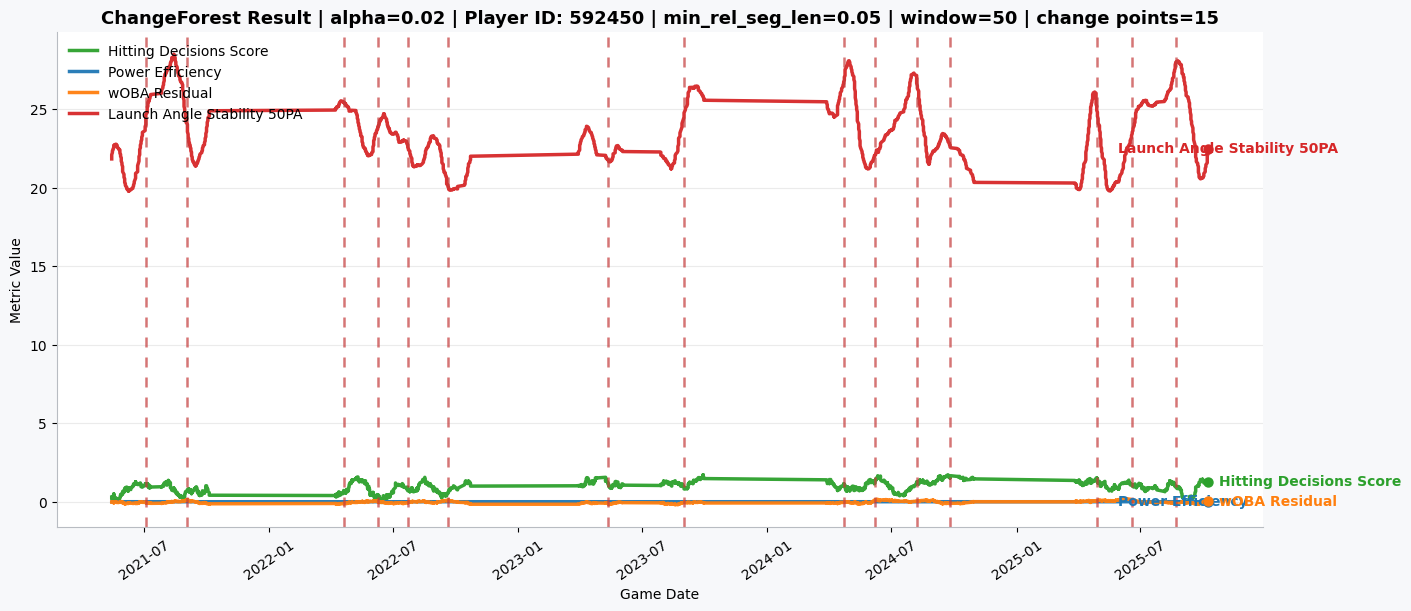

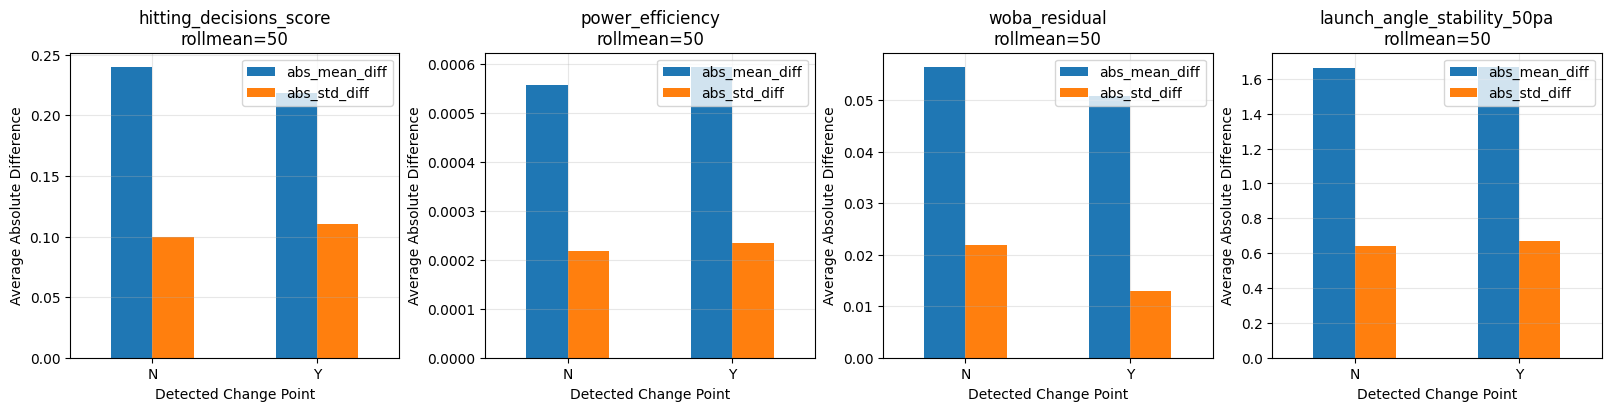

,window,minimal_relative_segment_length,n_change_points,change_points
0,50,0.01,63,"[30, 54, 85, 112, 143, 171, 199, 228, 258, 285..."
1,50,0.05,15,"[112, 228, 342, 461, 566, 686, 802, 914, 1025,..."
2,50,0.10,7,"[228, 461, 686, 914, 1132, 1357, 1579]"


In [13]:
selected_player_id = 592450
window = 50
min_rel_seg_len = 0.05

subdf = changeforest_subdataset_generator(
    df,
    selected_player_id=selected_player_id,
    window=window
)

result, cps, X_used, feature_names = run_changeforest(
    subdf,
    window=window,
    use_rollmean=True,
    standardize=True,
    minimal_relative_segment_length=min_rel_seg_len
)

print("Features used:", feature_names)
print("Detected change points (no.):", len(cps))
print("Detected change points:", cps)

if len(cps) > 0:
    print(subdf.iloc[cps][["cf_seq_id", "game_date", "pa_uid"]])

fig, axes = plot_changeforest_result(
    subdf,
    cps,
    window=window,
    use_rollmean=True,
    selected_player_id=selected_player_id,
    minimal_relative_segment_length=min_rel_seg_len
)
plt.show()

# 1. Before vs After Statistical Difference
# evaluation should follow actual feature_names
eval_dfs = build_cp_eval_dfs(
    subdf=subdf,
    cps=cps,
    feature_names=feature_names,
    compare_window=100   # this is evaluation window, not rolling window
)

fig, axes = plot_cp_eval_comparison(eval_dfs)
plt.show()

# 2. Robustness / Parameter Stability
cp_summary = run_parameter_stability_on_subdf(subdf=subdf, window=window)
display(cp_summary)
